# NVIDIA HMM Journey Analysis v2

This notebook builds on the full-data HMM outputs and creates the analysis-ready bridge between HMM weekly behavior states, HDBSCAN V11 lifecycle clusters, journey archetypes, transition interpretation, and presentation-ready visuals.

Main update from the first HMM analysis pass: state labels are refined so they describe weekly behavior, not permanent lifecycle identity. HDBSCAN remains the long-term lifecycle cohort, while HMM describes recent or sequential behavior.

## 0. Setup

In [1]:
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

DB_PATH = "developer_project.duckdb"
OUTPUT_DIR = Path("hmm_analysis_outputs_v2")
OUTPUT_DIR.mkdir(exist_ok=True)

con = duckdb.connect(DB_PATH)

HMM_WEEKLY = "dev_hmm_weekly_states_v1"
HMM_STATE_PROFILE = "dev_hmm_state_profile_v1"
HDBSCAN_FINAL = "dev_lifecycle_cluster_membership_v11_final"
HMM_JOURNEY = "dev_hmm_developer_journey_v1"
HMM_TRANSITION = "dev_hmm_transition_matrix_v1"

NVIDIA_GREEN = "#76B900"
PALETTE = {
    "active": "#76B900",
    "cooling": "#F4B400",
    "at_risk": "#DB4437",
    "dormant": "#5F6368",
    "unactivated": "#B0BEC5",
}

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

print("Connected to", DB_PATH)
print("Output directory:", OUTPUT_DIR.resolve())

Connected to developer_project.duckdb
Output directory: /Users/navsanya/Desktop/Spring2026_IndustryProject/hmm_analysis_outputs_v2


## 1. Confirm required HMM and HDBSCAN tables exist

In [2]:
required_tables = [
    HMM_WEEKLY,
    HMM_STATE_PROFILE,
    HMM_JOURNEY,
    HDBSCAN_FINAL,
]

existing_tables = set(con.execute("SHOW TABLES").fetchdf().iloc[:, 0].astype(str))
missing = [t for t in required_tables if t not in existing_tables]

if missing:
    raise RuntimeError(f"Missing required tables: {missing}")

print("All required tables found.")
for t in required_tables:
    n = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"{t}: {n:,} rows")

All required tables found.
dev_hmm_weekly_states_v1: 916,268 rows
dev_hmm_state_profile_v1: 8 rows
dev_hmm_developer_journey_v1: 150,000 rows
dev_lifecycle_cluster_membership_v11_final: 9,381,508 rows


## 2. Inspect HMM state profile

Use this table to verify whether the labels make sense. The HMM states are weekly behavior states. They should not be interpreted as permanent lifecycle segments.

In [3]:
print("HMM state profile schema:")
display(con.execute(f"DESCRIBE {HMM_STATE_PROFILE}").df())

state_profile = con.execute(f"""
SELECT *
FROM {HMM_STATE_PROFILE}
ORDER BY hmm_hidden_state
""").df()

display(state_profile)

HMM state profile schema:


,column_name,column_type,null,key,default,extra
0,hmm_hidden_state,BIGINT,YES,None,None,None
1,suggested_state_label,VARCHAR,YES,None,None,None
2,n_weekly_rows,BIGINT,YES,None,None,None
3,avg_state_probability,DOUBLE,YES,None,None,None
4,top_weekly_gmm_clusters,VARCHAR,YES,None,None,None
5,top_hdbscan_strata,VARCHAR,YES,None,None,None
6,top_hdbscan_clusters,VARCHAR,YES,None,None,None


,hmm_hidden_state,suggested_state_label,n_weekly_rows,avg_state_probability,top_weekly_gmm_clusters,top_hdbscan_strata,top_hdbscan_clusters
0,0,RENAME_STATE_0,33037,0.614233,0 (100.0%),"dormant (65.6%), at_risk (25.3%), cooling (5.0...","Dormant_Low_Depth (42.6%), Dormant_Former_Buil..."
1,1,RENAME_STATE_1,580588,0.786148,"0 (96.6%), 2 (3.2%), 1 (0.2%)","dormant (50.3%), at_risk (27.2%), active (14.1...","Dormant_Former_Builders (27.8%), Dormant_Low_D..."
2,2,RENAME_STATE_2,81068,0.663508,"0 (65.1%), 2 (32.8%), 1 (2.1%)","dormant (52.0%), at_risk (28.9%), active (10.0...","Dormant_Low_Depth (29.8%), Dormant_Former_Buil..."
3,3,RENAME_STATE_3,35153,0.700400,"0 (78.7%), 1 (16.6%), 2 (4.8%)","dormant (44.5%), at_risk (28.9%), active (15.0...","Dormant_Former_Builders (31.1%), active_noise ..."
4,4,RENAME_STATE_4,2918,0.827679,"1 (58.5%), 0 (26.3%), 2 (15.2%)","dormant (58.8%), at_risk (23.5%), active (9.7%...","Dormant_Low_Depth (30.4%), Dormant_Former_Buil..."
5,5,RENAME_STATE_5,10096,0.624510,"1 (91.2%), 0 (6.9%), 2 (1.9%)","dormant (44.8%), at_risk (24.6%), active (20.5...","Dormant_Low_Depth (24.6%), active_noise (20.4%..."
6,6,RENAME_STATE_6,162940,0.828413,"2 (81.5%), 0 (15.4%), 1 (3.0%)","dormant (62.8%), at_risk (23.7%), active (7.9%...","Dormant_Low_Depth (33.9%), Dormant_Former_Buil..."
7,7,RENAME_STATE_7,10468,0.620363,"1 (92.0%), 0 (6.3%), 2 (1.7%)","dormant (45.2%), at_risk (24.2%), active (20.3...","Dormant_Low_Depth (25.5%), active_noise (20.3%..."


## 3. Create refined HMM state labels

The prior analysis showed that state 1 dominates across all lifecycle cohorts. That means it should be labeled as a weekly behavior state, not as a dormant identity.

State 6 appears very often as the first state in `6 -> 1` journeys, so the safer label is **Prior Active / Starting Engagement** rather than assuming it always represents current high power usage.

In [4]:
HMM_STATE_LABELS = {
    0: "Idle / Minimal Weekly Activity",
    1: "Low Recent Activity / Lapsing",
    2: "Light At-Risk Engagement",
    3: "Cooling / Declining Engagement",
    4: "Active Exploration Burst",
    5: "Build-Oriented Weekly Usage",
    6: "Prior Active / Starting Engagement",
    7: "Irregular / Noisy Weekly Activity",
}

label_df = pd.DataFrame([
    {"hmm_hidden_state": state, "hmm_state_label": label}
    for state, label in HMM_STATE_LABELS.items()
])

con.register("label_df_view", label_df)
con.execute("""
CREATE OR REPLACE TABLE dev_hmm_state_labels_v2 AS
SELECT *
FROM label_df_view
""")
con.unregister("label_df_view")

print("Saved: dev_hmm_state_labels_v2")
display(label_df)

Saved: dev_hmm_state_labels_v2


,hmm_hidden_state,hmm_state_label
0,0,Idle / Minimal Weekly Activity
1,1,Low Recent Activity / Lapsing
2,2,Light At-Risk Engagement
3,3,Cooling / Declining Engagement
4,4,Active Exploration Burst
5,5,Build-Oriented Weekly Usage
6,6,Prior Active / Starting Engagement
7,7,Irregular / Noisy Weekly Activity


## 4. Rebuild HMM to HDBSCAN alignment

This table connects recent HMM behavior to the long-term HDBSCAN lifecycle cohort.

Interpretation:

- HDBSCAN = stable lifecycle / aggregate behavioral identity
- HMM latest state = most recent weekly behavior
- mismatch patterns are useful early-warning or recovery signals

In [5]:
hmm_hdbscan = con.execute(f"""
WITH latest_hmm AS (
    SELECT
        developer_id,
        week_start,
        hmm_hidden_state,
        hmm_state_probability,
        ROW_NUMBER() OVER (
            PARTITION BY developer_id
            ORDER BY week_start DESC
        ) AS rn
    FROM {HMM_WEEKLY}
)

SELECT
    h.developer_id,
    h.week_start AS latest_hmm_week_start,
    h.hmm_hidden_state,
    l.hmm_state_label,
    h.hmm_state_probability,
    c.stratum,
    c.cluster_key,
    c.hdbscan_cluster,
    c.cluster_probability,
    c.outlier_score,
    c.adoption_direction
FROM latest_hmm h
LEFT JOIN dev_hmm_state_labels_v2 l
    ON h.hmm_hidden_state = l.hmm_hidden_state
LEFT JOIN {HDBSCAN_FINAL} c
    ON h.developer_id = c.developer_id
WHERE h.rn = 1
""").df()

con.register("hmm_hdbscan_view", hmm_hdbscan)
con.execute("""
CREATE OR REPLACE TABLE dev_hmm_hdbscan_alignment_v2 AS
SELECT *
FROM hmm_hdbscan_view
""")
con.unregister("hmm_hdbscan_view")

print("Saved: dev_hmm_hdbscan_alignment_v2")
display(hmm_hdbscan.head())
print("Rows:", len(hmm_hdbscan))

Saved: dev_hmm_hdbscan_alignment_v2


,developer_id,latest_hmm_week_start,hmm_hidden_state,hmm_state_label,hmm_state_probability,stratum,cluster_key,hdbscan_cluster,cluster_probability,outlier_score,adoption_direction
0,4399528,2026-03-09,3,Cooling / Declining Engagement,0.516659,active,active_noise,-1,0.0,NaN,accelerating_or_active
1,3578710,2026-03-02,2,Light At-Risk Engagement,0.881447,active,active_noise,-1,0.0,NaN,accelerating_or_active
2,6032129,2026-03-09,1,Low Recent Activity / Lapsing,0.833793,active,active_noise,-1,0.0,NaN,accelerating_or_active
3,5120796,2026-02-16,1,Low Recent Activity / Lapsing,0.864049,active,active_noise,-1,0.0,NaN,accelerating_or_active
4,6606354,2026-03-02,1,Low Recent Activity / Lapsing,0.653305,active,active_noise,-1,0.0,NaN,accelerating_or_active


Rows: 150000


## 5. HMM lifecycle signal summary

This summary is the easiest way to explain how recent HMM behavior differs by lifecycle stratum.

In [6]:
lifecycle_signal = con.execute("""
SELECT
    stratum,
    hmm_hidden_state,
    hmm_state_label,
    COUNT(*) AS n_developers,
    AVG(hmm_state_probability) AS avg_hmm_state_probability
FROM dev_hmm_hdbscan_alignment_v2
GROUP BY
    stratum,
    hmm_hidden_state,
    hmm_state_label
ORDER BY
    stratum,
    n_developers DESC
""").df()

con.register("lifecycle_signal_view", lifecycle_signal)
con.execute("""
CREATE OR REPLACE TABLE dev_hmm_lifecycle_signal_summary_v2 AS
SELECT *
FROM lifecycle_signal_view
""")
con.unregister("lifecycle_signal_view")

print("Saved: dev_hmm_lifecycle_signal_summary_v2")
display(lifecycle_signal)

Saved: dev_hmm_lifecycle_signal_summary_v2


,stratum,hmm_hidden_state,hmm_state_label,n_developers,avg_hmm_state_probability
0,active,1,Low Recent Activity / Lapsing,11948,0.810056
1,active,2,Light At-Risk Engagement,328,0.587781
2,active,3,Cooling / Declining Engagement,312,0.651838
3,active,5,Build-Oriented Weekly Usage,140,0.615814
4,active,6,Prior Active / Starting Engagement,101,0.434812
5,active,7,Irregular / Noisy Weekly Activity,76,0.577009
6,at_risk,1,Low Recent Activity / Lapsing,31559,0.758246
7,at_risk,2,Light At-Risk Engagement,2149,0.604441
8,at_risk,6,Prior Active / Starting Engagement,1412,0.449212
9,at_risk,3,Cooling / Declining Engagement,973,0.616862


## 6. HMM to HDBSCAN cluster alignment summary

This creates the detailed crosswalk by lifecycle stratum, HDBSCAN cluster, and latest HMM state.

In [7]:
alignment_summary = con.execute("""
SELECT
    stratum,
    cluster_key,
    hmm_hidden_state,
    hmm_state_label,
    COUNT(*) AS n_developers,
    AVG(hmm_state_probability) AS avg_hmm_state_probability,
    AVG(cluster_probability) AS avg_hdbscan_cluster_probability,
    AVG(outlier_score) AS avg_hdbscan_outlier_score
FROM dev_hmm_hdbscan_alignment_v2
GROUP BY
    stratum,
    cluster_key,
    hmm_hidden_state,
    hmm_state_label
ORDER BY
    stratum,
    cluster_key,
    n_developers DESC
""").df()

con.register("alignment_summary_view", alignment_summary)
con.execute("""
CREATE OR REPLACE TABLE dev_hmm_hdbscan_alignment_summary_v2 AS
SELECT *
FROM alignment_summary_view
""")
con.unregister("alignment_summary_view")

print("Saved: dev_hmm_hdbscan_alignment_summary_v2")
display(alignment_summary.head(50))

Saved: dev_hmm_hdbscan_alignment_summary_v2


,stratum,cluster_key,hmm_hidden_state,hmm_state_label,n_developers,avg_hmm_state_probability,avg_hdbscan_cluster_probability,avg_hdbscan_outlier_score
0,active,active_0,6,Prior Active / Starting Engagement,6,0.464742,0.876742,0.123258
1,active,active_0,1,Low Recent Activity / Lapsing,6,0.718556,0.793165,0.206835
2,active,active_1,1,Low Recent Activity / Lapsing,2144,0.763138,0.867727,0.132273
3,active,active_1,6,Prior Active / Starting Engagement,4,0.486790,0.327640,0.672360
4,active,active_1,2,Light At-Risk Engagement,1,0.536485,0.120724,0.879276
5,active,active_2,1,Low Recent Activity / Lapsing,13,0.656739,0.715765,0.284235
6,active,active_2,6,Prior Active / Starting Engagement,3,0.506943,0.750742,0.249258
7,active,active_2,5,Build-Oriented Weekly Usage,2,0.603379,0.708791,0.291209
8,active,active_2,3,Cooling / Declining Engagement,1,0.299194,0.631313,0.368687
9,active,active_3,1,Low Recent Activity / Lapsing,3099,0.858419,0.917098,0.082902


## 7. Journey archetype summary with labels

This is the main table for telling the HMM story. It converts first, last, and dominant HMM states into readable journey archetypes.

In [8]:
journey_summary = con.execute(f"""
WITH base AS (
    SELECT
        j.*,
        lf.hmm_state_label AS first_hmm_state_label,
        ll.hmm_state_label AS last_hmm_state_label,
        ld.hmm_state_label AS dominant_hmm_state_label
    FROM {HMM_JOURNEY} j
    LEFT JOIN dev_hmm_state_labels_v2 lf
        ON j.first_hmm_state = lf.hmm_hidden_state
    LEFT JOIN dev_hmm_state_labels_v2 ll
        ON j.last_hmm_state = ll.hmm_hidden_state
    LEFT JOIN dev_hmm_state_labels_v2 ld
        ON j.dominant_hmm_state = ld.hmm_hidden_state
)
SELECT
    first_hmm_state,
    first_hmm_state_label,
    last_hmm_state,
    last_hmm_state_label,
    dominant_hmm_state,
    dominant_hmm_state_label,
    stratum,
    cluster_key,
    COUNT(*) AS n_developers,
    AVG(avg_state_probability) AS avg_state_probability,
    AVG(hmm_state_entropy) AS avg_hmm_state_entropy
FROM base
GROUP BY
    first_hmm_state,
    first_hmm_state_label,
    last_hmm_state,
    last_hmm_state_label,
    dominant_hmm_state,
    dominant_hmm_state_label,
    stratum,
    cluster_key
ORDER BY n_developers DESC
""").df()

journey_summary["journey_label"] = (
    journey_summary["first_hmm_state_label"].astype(str)
    + " -> "
    + journey_summary["last_hmm_state_label"].astype(str)
)

con.register("journey_summary_view", journey_summary)
con.execute("""
CREATE OR REPLACE TABLE dev_hmm_journey_archetype_summary_v2 AS
SELECT *
FROM journey_summary_view
""")
con.unregister("journey_summary_view")

print("Saved: dev_hmm_journey_archetype_summary_v2")
display(journey_summary.head(50))

Saved: dev_hmm_journey_archetype_summary_v2


,first_hmm_state,first_hmm_state_label,last_hmm_state,last_hmm_state_label,dominant_hmm_state,dominant_hmm_state_label,stratum,cluster_key,n_developers,avg_state_probability,avg_hmm_state_entropy,journey_label
0,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,dormant,Dormant_Former_Builders,33397,0.794055,0.540210,Prior Active / Starting Engagement -> Low Rece...
1,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,dormant,Dormant_Low_Depth,31563,0.757921,0.565013,Prior Active / Starting Engagement -> Low Rece...
2,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,at_risk,at_risk_5,14747,0.778526,0.540200,Prior Active / Starting Engagement -> Low Rece...
3,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,at_risk,at_risk_0,7227,0.791881,0.522532,Prior Active / Starting Engagement -> Low Rece...
4,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,active,active_noise,5914,0.811469,0.457167,Prior Active / Starting Engagement -> Low Rece...
5,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,at_risk,at_risk_noise,5057,0.768874,0.468652,Prior Active / Starting Engagement -> Low Rece...
6,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,cooling,cooling_noise,5054,0.801187,0.468699,Prior Active / Starting Engagement -> Low Rece...
7,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,active,active_3,3060,0.870389,0.456882,Prior Active / Starting Engagement -> Low Rece...
8,0,Idle / Minimal Weekly Activity,1,Low Recent Activity / Lapsing,0,Idle / Minimal Weekly Activity,dormant,Dormant_Low_Depth,2719,0.643151,1.074627,Idle / Minimal Weekly Activity -> Low Recent A...
9,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,6,Prior Active / Starting Engagement,dormant,Dormant_Low_Depth,2590,0.733513,0.637909,Prior Active / Starting Engagement -> Low Rece...


## 8. Presentation visual 1: HMM latest-state distribution by lifecycle

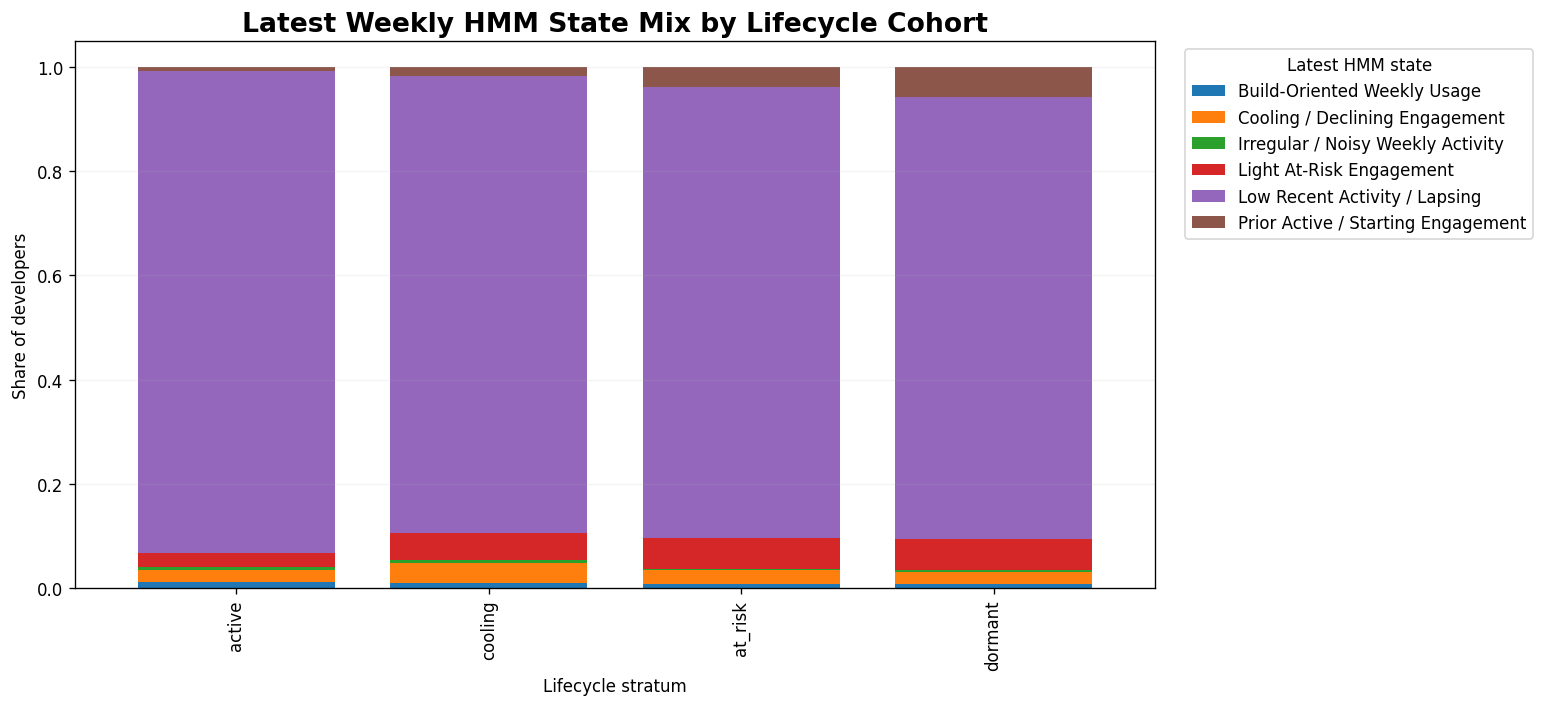

In [9]:
plot_df = lifecycle_signal.copy()
plot_df["share_within_stratum"] = plot_df["n_developers"] / plot_df.groupby("stratum")["n_developers"].transform("sum")

pivot = plot_df.pivot_table(
    index="stratum",
    columns="hmm_state_label",
    values="share_within_stratum",
    aggfunc="sum",
    fill_value=0,
)

order = [s for s in ["active", "cooling", "at_risk", "dormant", "unactivated"] if s in pivot.index]
pivot = pivot.loc[order]

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind="bar", stacked=True, ax=ax, width=0.78)
ax.set_title("Latest Weekly HMM State Mix by Lifecycle Cohort", fontsize=16, weight="bold")
ax.set_xlabel("Lifecycle stratum")
ax.set_ylabel("Share of developers")
ax.legend(title="Latest HMM state", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
ax.grid(axis="y", alpha=0.15)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "hmm_latest_state_mix_by_lifecycle.png", bbox_inches="tight")
plt.show()

## 9. Presentation visual 2: Top journey archetypes

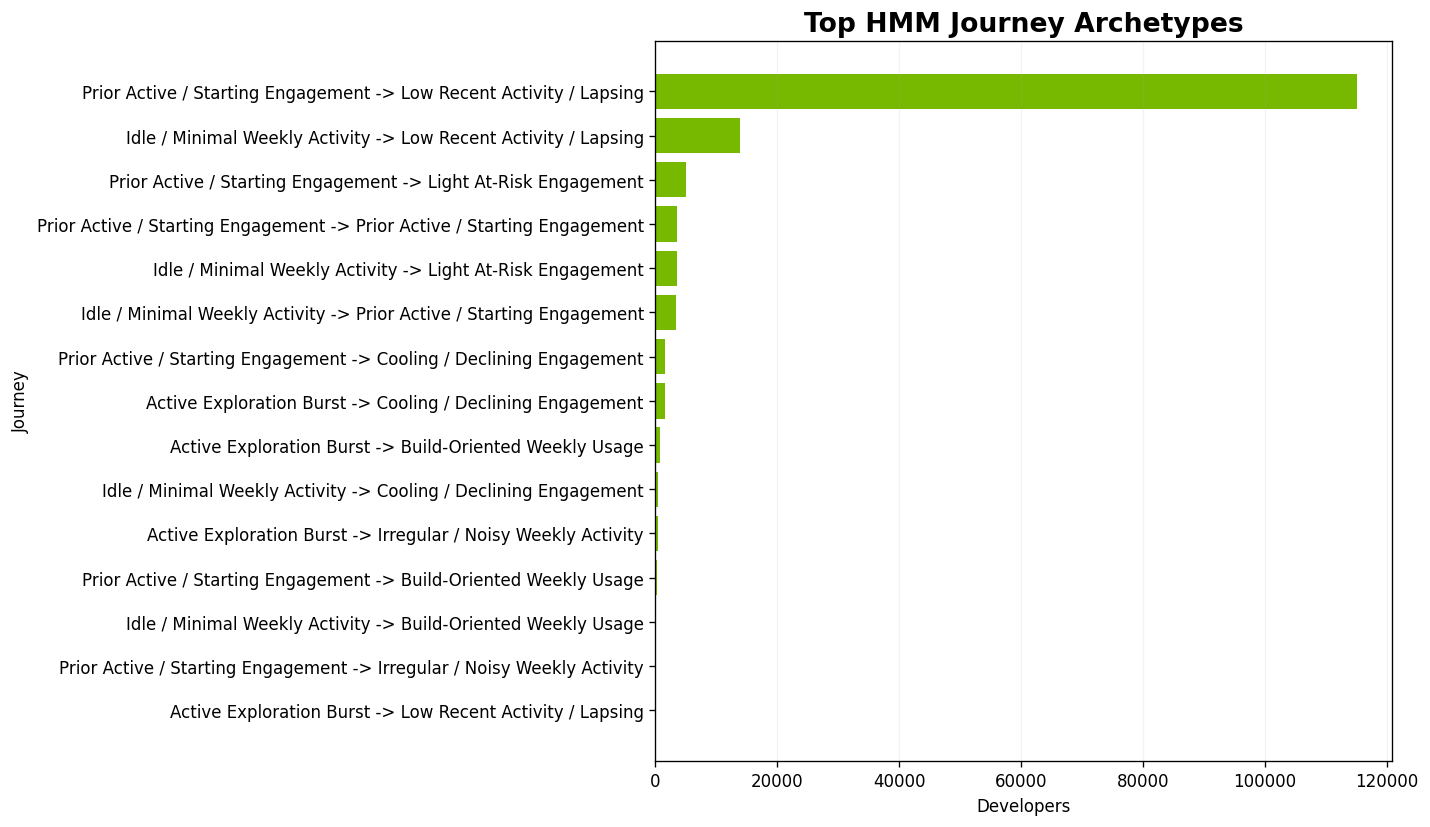

,journey_label,n_developers
15,Prior Active / Starting Engagement -> Low Rece...,115083
9,Idle / Minimal Weekly Activity -> Low Recent A...,13839
14,Prior Active / Starting Engagement -> Light At...,4993
16,Prior Active / Starting Engagement -> Prior Ac...,3613
8,Idle / Minimal Weekly Activity -> Light At-Ris...,3454
10,Idle / Minimal Weekly Activity -> Prior Active...,3352
12,Prior Active / Starting Engagement -> Cooling ...,1624
1,Active Exploration Burst -> Cooling / Declinin...,1610
0,Active Exploration Burst -> Build-Oriented Wee...,737
6,Idle / Minimal Weekly Activity -> Cooling / De...,488


In [10]:
top_journeys = (
    journey_summary
    .groupby("journey_label", as_index=False)["n_developers"]
    .sum()
    .sort_values("n_developers", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_journeys["journey_label"], top_journeys["n_developers"], color=NVIDIA_GREEN)
ax.invert_yaxis()
ax.set_title("Top HMM Journey Archetypes", fontsize=16, weight="bold")
ax.set_xlabel("Developers")
ax.set_ylabel("Journey")
ax.grid(axis="x", alpha=0.15)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "top_hmm_journey_archetypes.png", bbox_inches="tight")
plt.show()

display(top_journeys)

## 10. Presentation visual 3: HMM state by HDBSCAN stratum heatmap

This heatmap is usually easier to explain than a full cluster-level heatmap.

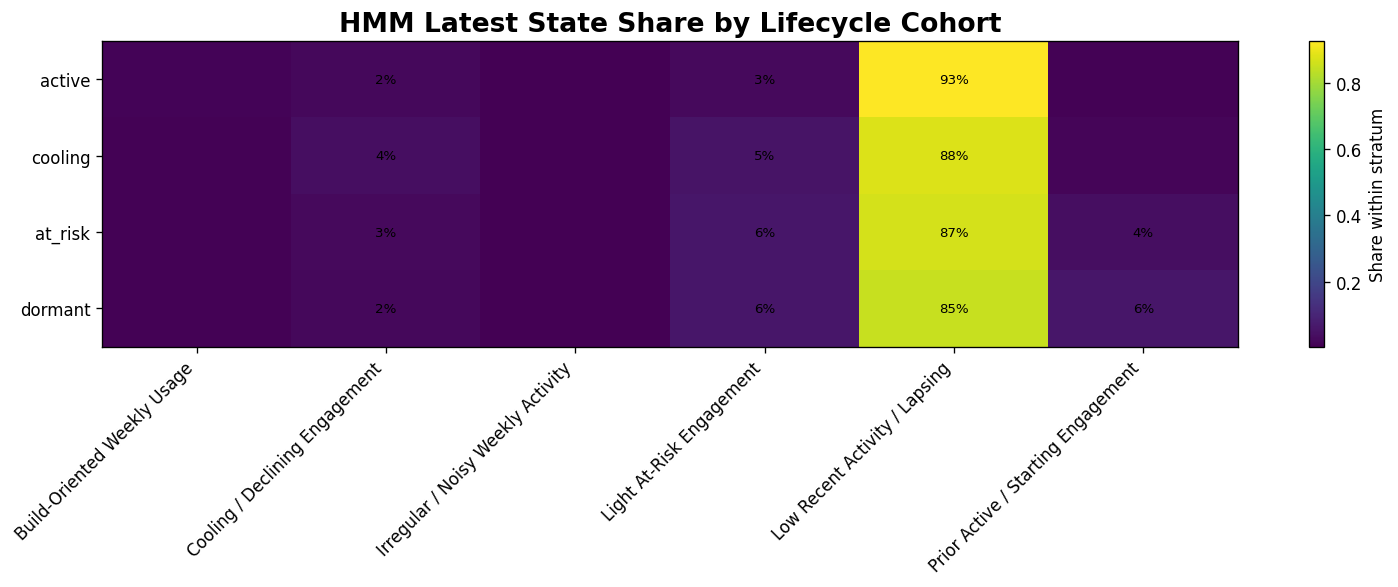

In [11]:
heat = lifecycle_signal.copy()
heat["share_within_stratum"] = heat["n_developers"] / heat.groupby("stratum")["n_developers"].transform("sum")
heat_pivot = heat.pivot_table(
    index="stratum",
    columns="hmm_state_label",
    values="share_within_stratum",
    fill_value=0,
    aggfunc="sum"
)
heat_pivot = heat_pivot.loc[[s for s in ["active", "cooling", "at_risk", "dormant"] if s in heat_pivot.index]]

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(heat_pivot.values, aspect="auto")
ax.set_xticks(range(len(heat_pivot.columns)))
ax.set_xticklabels(heat_pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heat_pivot.index)))
ax.set_yticklabels(heat_pivot.index)
ax.set_title("HMM Latest State Share by Lifecycle Cohort", fontsize=16, weight="bold")

for i in range(heat_pivot.shape[0]):
    for j in range(heat_pivot.shape[1]):
        val = heat_pivot.values[i, j]
        if val > 0.02:
            ax.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Share within stratum")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "hmm_state_by_lifecycle_heatmap.png", bbox_inches="tight")
plt.show()

## 11. Create business signal flags

These flags are useful for asset impact and recommendations.

In [12]:
signals = con.execute("""
SELECT
    *,
    CASE
        WHEN stratum = 'active'
             AND hmm_state_label IN ('Low Recent Activity / Lapsing', 'Cooling / Declining Engagement')
        THEN 1 ELSE 0
    END AS early_warning_active_flag,

    CASE
        WHEN stratum IN ('at_risk', 'cooling')
             AND hmm_state_label IN ('Build-Oriented Weekly Usage', 'Prior Active / Starting Engagement')
        THEN 1 ELSE 0
    END AS recovery_candidate_flag,

    CASE
        WHEN stratum = 'dormant'
             AND hmm_state_label IN ('Prior Active / Starting Engagement', 'Build-Oriented Weekly Usage')
        THEN 1 ELSE 0
    END AS dormant_reactivation_signal_flag

FROM dev_hmm_hdbscan_alignment_v2
""").df()

con.register("signals_view", signals)
con.execute("""
CREATE OR REPLACE TABLE dev_hmm_business_signals_v2 AS
SELECT *
FROM signals_view
""")
con.unregister("signals_view")

print("Saved: dev_hmm_business_signals_v2")

display(signals[[
    "early_warning_active_flag",
    "recovery_candidate_flag",
    "dormant_reactivation_signal_flag"
]].sum().reset_index().rename(columns={"index": "signal", 0: "n_developers"}))

Saved: dev_hmm_business_signals_v2


,signal,n_developers
0,early_warning_active_flag,12260
1,recovery_candidate_flag,1903
2,dormant_reactivation_signal_flag,6005


## 12. Export HMM v2 outputs to parquet

In [13]:
EXPORT_DIR = Path("team_export_parquet")
EXPORT_DIR.mkdir(exist_ok=True)

hmm_v2_tables = [
    "dev_hmm_state_labels_v2",
    "dev_hmm_hdbscan_alignment_v2",
    "dev_hmm_lifecycle_signal_summary_v2",
    "dev_hmm_hdbscan_alignment_summary_v2",
    "dev_hmm_journey_archetype_summary_v2",
    "dev_hmm_business_signals_v2",
]

manifest = []
for table in hmm_v2_tables:
    out_path = EXPORT_DIR / f"{table}.parquet"
    n = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    con.execute(f"""
        COPY {table}
        TO '{out_path.as_posix()}'
        (FORMAT PARQUET)
    """)
    manifest.append({"table_name": table, "rows": n, "path": out_path.as_posix()})
    print(f"Exported {table}: {n:,} rows -> {out_path}")

manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv(EXPORT_DIR / "hmm_v2_export_manifest.csv", index=False)
display(manifest_df)

Exported dev_hmm_state_labels_v2: 8 rows -> team_export_parquet/dev_hmm_state_labels_v2.parquet
Exported dev_hmm_hdbscan_alignment_v2: 150,000 rows -> team_export_parquet/dev_hmm_hdbscan_alignment_v2.parquet
Exported dev_hmm_lifecycle_signal_summary_v2: 24 rows -> team_export_parquet/dev_hmm_lifecycle_signal_summary_v2.parquet
Exported dev_hmm_hdbscan_alignment_summary_v2: 71 rows -> team_export_parquet/dev_hmm_hdbscan_alignment_summary_v2.parquet
Exported dev_hmm_journey_archetype_summary_v2: 389 rows -> team_export_parquet/dev_hmm_journey_archetype_summary_v2.parquet
Exported dev_hmm_business_signals_v2: 150,000 rows -> team_export_parquet/dev_hmm_business_signals_v2.parquet


,table_name,rows,path
0,dev_hmm_state_labels_v2,8,team_export_parquet/dev_hmm_state_labels_v2.pa...
1,dev_hmm_hdbscan_alignment_v2,150000,team_export_parquet/dev_hmm_hdbscan_alignment_...
2,dev_hmm_lifecycle_signal_summary_v2,24,team_export_parquet/dev_hmm_lifecycle_signal_s...
3,dev_hmm_hdbscan_alignment_summary_v2,71,team_export_parquet/dev_hmm_hdbscan_alignment_...
4,dev_hmm_journey_archetype_summary_v2,389,team_export_parquet/dev_hmm_journey_archetype_...
5,dev_hmm_business_signals_v2,150000,team_export_parquet/dev_hmm_business_signals_v...


## 14. Cluster × Journey Targeting Analysis

Combines **V11 HDBSCAN persona clusters** with **HMM weekly journey behavior** to identify cluster-specific journey patterns and targeting opportunities.

Run **14.0** first (standalone-safe if v1 HMM parquets are loaded in DuckDB). Outputs land in `hmm_analysis_outputs_v2/`.

**Population:** All **valid HMM-scored developers** in `dev_hmm_weekly_states_v1` (every developer with ≥3 weekly rows and a V11 cluster assignment). This is the full HMM inference cohort (~150K), not a journey-table subsample. Clusters with no HMM-scored developers are omitted.

In [1]:
# 14.0 Standalone bootstrap
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DB_PATH = "developer_project.duckdb"
OUTPUT_DIR = Path("hmm_analysis_outputs_v2")
OUTPUT_DIR.mkdir(exist_ok=True)
MIN_CLUSTER_N = 1  # include all clusters with any HMM-scored developers
SPARSE_CLUSTER_N = 30  # annotation threshold only (does not exclude from analysis)
WRITE_TABLES = True

HMM_STATE_LABELS = {
    0: "Idle / Minimal Weekly Activity",
    1: "Low Recent Activity / Lapsing",
    2: "Light At-Risk Engagement",
    3: "Cooling / Declining Engagement",
    4: "Active Exploration Burst",
    5: "Build-Oriented Weekly Usage",
    6: "Prior Active / Starting Engagement",
    7: "Irregular / Noisy Weekly Activity",
}

NVIDIA_GREEN = "#76B900"
PALETTE = {
    "active": "#76B900",
    "cooling": "#F4B400",
    "at_risk": "#DB4437",
    "dormant": "#5F6368",
    "unactivated": "#B0BEC5",
}

state_label_order = [HMM_STATE_LABELS[i] for i in sorted(HMM_STATE_LABELS)]

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

try:
    con.execute("SELECT 1").fetchone()
except Exception:
    con = duckdb.connect(DB_PATH)

REQUIRED_TABLES = [
    "dev_hmm_weekly_states_v1",
    "dev_v11_cluster_names",
    "dev_lifecycle_cluster_membership_v11_final",
]

existing = set(con.execute("SHOW TABLES").fetchdf().iloc[:, 0].astype(str))
missing = [t for t in REQUIRED_TABLES if t not in existing]
if missing:
    raise RuntimeError(f"Missing required tables: {missing}. Load toexport_HMM/ parquets first.")

label_df = pd.DataFrame([
    {"hmm_hidden_state": state, "hmm_state_label": label}
    for state, label in HMM_STATE_LABELS.items()
])
con.register("_label_df", label_df)
con.execute("CREATE OR REPLACE TEMP TABLE hmm_state_labels_v2_view AS SELECT * FROM _label_df")
con.unregister("_label_df")

# All developers with HMM weekly rows + V11 persona names
con.execute("""
CREATE OR REPLACE TEMP VIEW v_hmm_valid_developers AS
SELECT DISTINCT
    n.developer_id,
    n.stratum,
    n.cluster_key,
    n.persona_feature_name,
    n.persona_technical_name,
    n.demographic_audience,
    n.demographic_archetypes,
    n.is_ghost_cluster,
    n.cluster_label_slide,
    n.cluster_label_combined
FROM dev_hmm_weekly_states_v1 w
JOIN dev_v11_cluster_names n
  ON w.developer_id = n.developer_id
""")

# Journey metrics derived from weekly states for every valid developer
con.execute("""
CREATE OR REPLACE TEMP VIEW v_hmm_dev_journey_from_weekly AS
SELECT
    d.developer_id,
    d.stratum,
    d.cluster_key,
    d.persona_feature_name,
    d.persona_technical_name,
    d.demographic_audience,
    d.demographic_archetypes,
    d.is_ghost_cluster,
    d.cluster_label_slide,
    d.cluster_label_combined,
    COUNT(*) AS n_weeks,
    arg_min(w.hmm_hidden_state, w.week_start) AS first_hmm_state,
    arg_max(w.hmm_hidden_state, w.week_start) AS last_hmm_state,
    mode(w.hmm_hidden_state) AS dominant_hmm_state,
    MIN(w.week_start) AS first_week,
    MAX(w.week_start) AS last_week,
    AVG(w.hmm_state_probability) AS avg_state_probability
FROM dev_hmm_weekly_states_v1 w
JOIN v_hmm_valid_developers d
  ON w.developer_id = d.developer_id
GROUP BY
    d.developer_id, d.stratum, d.cluster_key, d.persona_feature_name,
    d.persona_technical_name, d.demographic_audience, d.demographic_archetypes,
    d.is_ghost_cluster, d.cluster_label_slide, d.cluster_label_combined
""")

n_valid = con.execute("SELECT COUNT(*) FROM v_hmm_valid_developers").fetchone()[0]
n_weekly_rows = con.execute("SELECT COUNT(*) FROM dev_hmm_weekly_states_v1").fetchone()[0]
n_clusters_in_hmm = con.execute("SELECT COUNT(DISTINCT cluster_key) FROM v_hmm_valid_developers").fetchone()[0]
n_clusters_full = con.execute(
    "SELECT COUNT(DISTINCT cluster_key) FROM dev_lifecycle_cluster_membership_v11_final"
).fetchone()[0]

print(f"Valid HMM-scored developers: {n_valid:,}")
print(f"Weekly HMM rows: {n_weekly_rows:,}")
print(f"Clusters with HMM data: {n_clusters_in_hmm} / {n_clusters_full} total V11 clusters")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


HMM sample developers: 150,000
Clusters in HMM sample: 18 / 26 total V11 clusters
MIN_CLUSTER_N for visuals: 30
Output directory: /Users/pmazolew/Documents/GitHub/Spring2026_IndustryProject/hmm_analysis_outputs_v2


### 14.1 Cluster HMM state distribution (time spent)

Share of **weekly rows** in each HMM state, by V11 cluster (full observed timeline per developer).

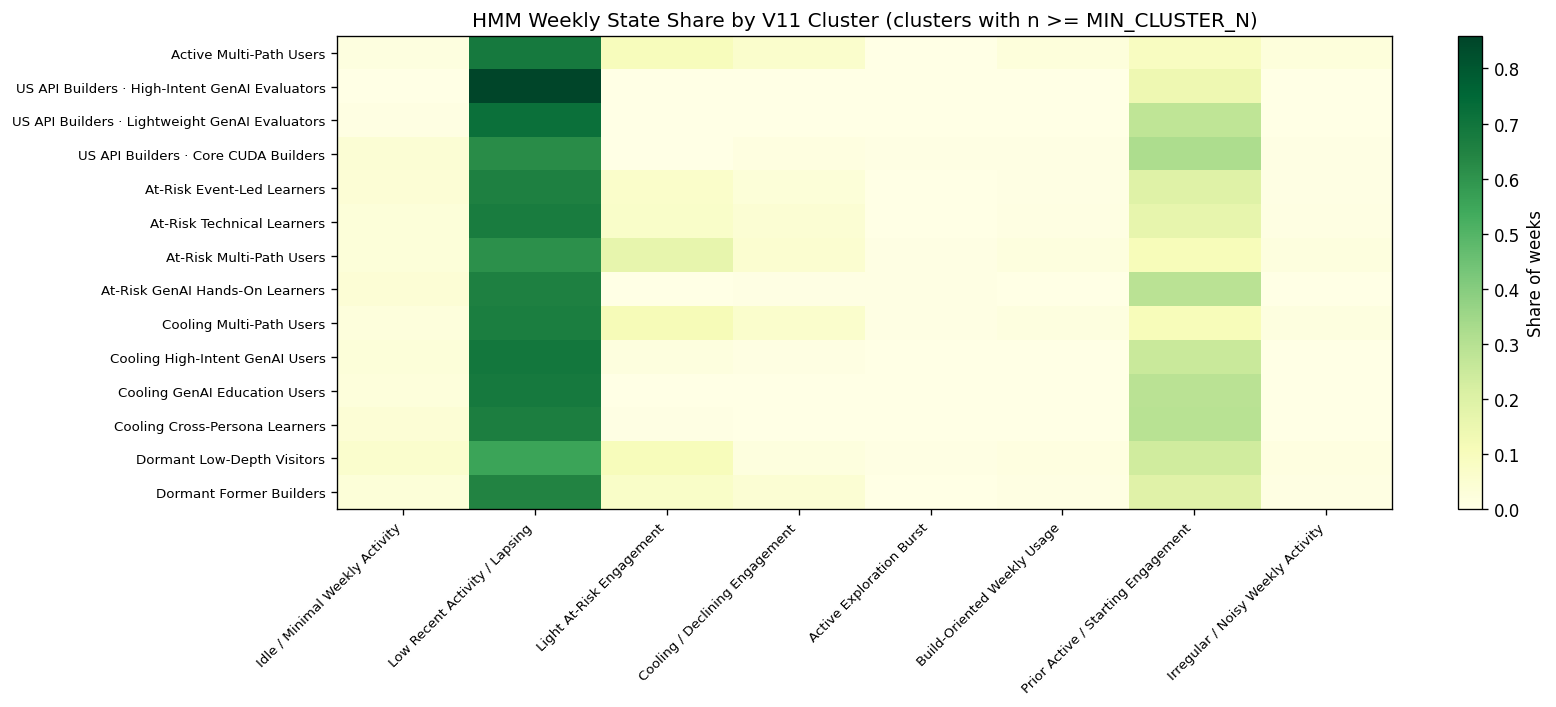

Saved: hmm_analysis_outputs_v2/cluster_hmm_state_distribution_v2.csv


,stratum,cluster_key,persona_feature_name,cluster_label_slide,hmm_hidden_state,hmm_state_label,n_weeks,n_developers,share_within_cluster
0,active,active_0,GenAI Evaluation Cohort,APAC Learners · GenAI Evaluation Cohort,6,Prior Active / Starting Engagement,18,12,0.473684
1,active,active_0,GenAI Evaluation Cohort,APAC Learners · GenAI Evaluation Cohort,1,Low Recent Activity / Lapsing,12,6,0.315789
2,active,active_0,GenAI Evaluation Cohort,APAC Learners · GenAI Evaluation Cohort,0,Idle / Minimal Weekly Activity,8,5,0.210526
3,active,active_1,Lightweight GenAI Evaluators,US API Builders · Lightweight GenAI Evaluators,1,Low Recent Activity / Lapsing,5536,2144,0.715153
4,active,active_1,Lightweight GenAI Evaluators,US API Builders · Lightweight GenAI Evaluators,6,Prior Active / Starting Engagement,2149,2148,0.277613
5,active,active_1,Lightweight GenAI Evaluators,US API Builders · Lightweight GenAI Evaluators,0,Idle / Minimal Weekly Activity,52,36,0.006717
6,active,active_1,Lightweight GenAI Evaluators,US API Builders · Lightweight GenAI Evaluators,2,Light At-Risk Engagement,4,1,0.000517
7,active,active_2,GenAI Community Participants,APAC Learners · GenAI Community Participants,1,Low Recent Activity / Lapsing,26,13,0.433333
8,active,active_2,GenAI Community Participants,APAC Learners · GenAI Community Participants,6,Prior Active / Starting Engagement,16,16,0.266667
9,active,active_2,GenAI Community Participants,APAC Learners · GenAI Community Participants,0,Idle / Minimal Weekly Activity,8,4,0.133333


In [2]:
# 14.1 — weekly state distribution by cluster
state_dist = con.execute("""
WITH weekly AS (
    SELECT
        s.stratum,
        s.cluster_key,
        s.persona_feature_name,
        s.cluster_label_slide,
        w.hmm_hidden_state,
        w.developer_id
    FROM dev_hmm_weekly_states_v1 w
    INNER JOIN v_hmm_valid_developers s
        ON w.developer_id = s.developer_id
)
SELECT
    w.stratum,
    w.cluster_key,
    w.persona_feature_name,
    w.cluster_label_slide,
    w.hmm_hidden_state,
    l.hmm_state_label,
    COUNT(*) AS n_weeks,
    COUNT(DISTINCT w.developer_id) AS n_developers
FROM weekly w
JOIN hmm_state_labels_v2_view l
    ON w.hmm_hidden_state = l.hmm_hidden_state
GROUP BY 1, 2, 3, 4, 5, 6
ORDER BY stratum, cluster_key, n_weeks DESC
""").fetchdf()

state_dist["share_within_cluster"] = (
    state_dist.groupby(["stratum", "cluster_key"])["n_weeks"].transform(lambda s: s / s.sum())
)

cluster_hmm_state_distribution_v2 = state_dist.copy()

plot_df = state_dist.copy()
cluster_order = (
    state_dist.groupby(["stratum", "cluster_key", "cluster_label_slide"], as_index=False)["n_developers"]
    .max()
    .sort_values(["stratum", "n_developers"], ascending=[True, False])
)
plot_df = plot_df.merge(cluster_order[["cluster_key", "cluster_label_slide"]], on=["cluster_key", "cluster_label_slide"])
plot_df["cluster_label_slide"] = pd.Categorical(
    plot_df["cluster_label_slide"],
    categories=cluster_order["cluster_label_slide"].tolist(),
    ordered=True,
)

pivot = plot_df.pivot_table(
    index="cluster_label_slide",
    columns="hmm_state_label",
    values="share_within_cluster",
    aggfunc="sum",
    fill_value=0,
)
pivot = pivot.reindex(columns=[c for c in state_label_order if c in pivot.columns])

fig, ax = plt.subplots(figsize=(14, max(6, 0.35 * len(pivot))))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlGn")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_title("HMM Weekly State Share by V11 Cluster (all valid HMM-scored developers)")
fig.colorbar(im, ax=ax, label="Share of weeks")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "cluster_hmm_state_distribution_heatmap.png", bbox_inches="tight")
plt.show()

if WRITE_TABLES:
    con.register("_state_dist", cluster_hmm_state_distribution_v2)
    con.execute("CREATE OR REPLACE TABLE cluster_hmm_state_distribution_v2 AS SELECT * FROM _state_dist")
    con.unregister("_state_dist")

cluster_hmm_state_distribution_v2.to_csv(OUTPUT_DIR / "cluster_hmm_state_distribution_v2.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'cluster_hmm_state_distribution_v2.csv'}")
display(cluster_hmm_state_distribution_v2.head(12))


### 14.2 Latest HMM state by cluster (snapshot)

Most recent weekly HMM state per developer — useful for **current** targeting signals.

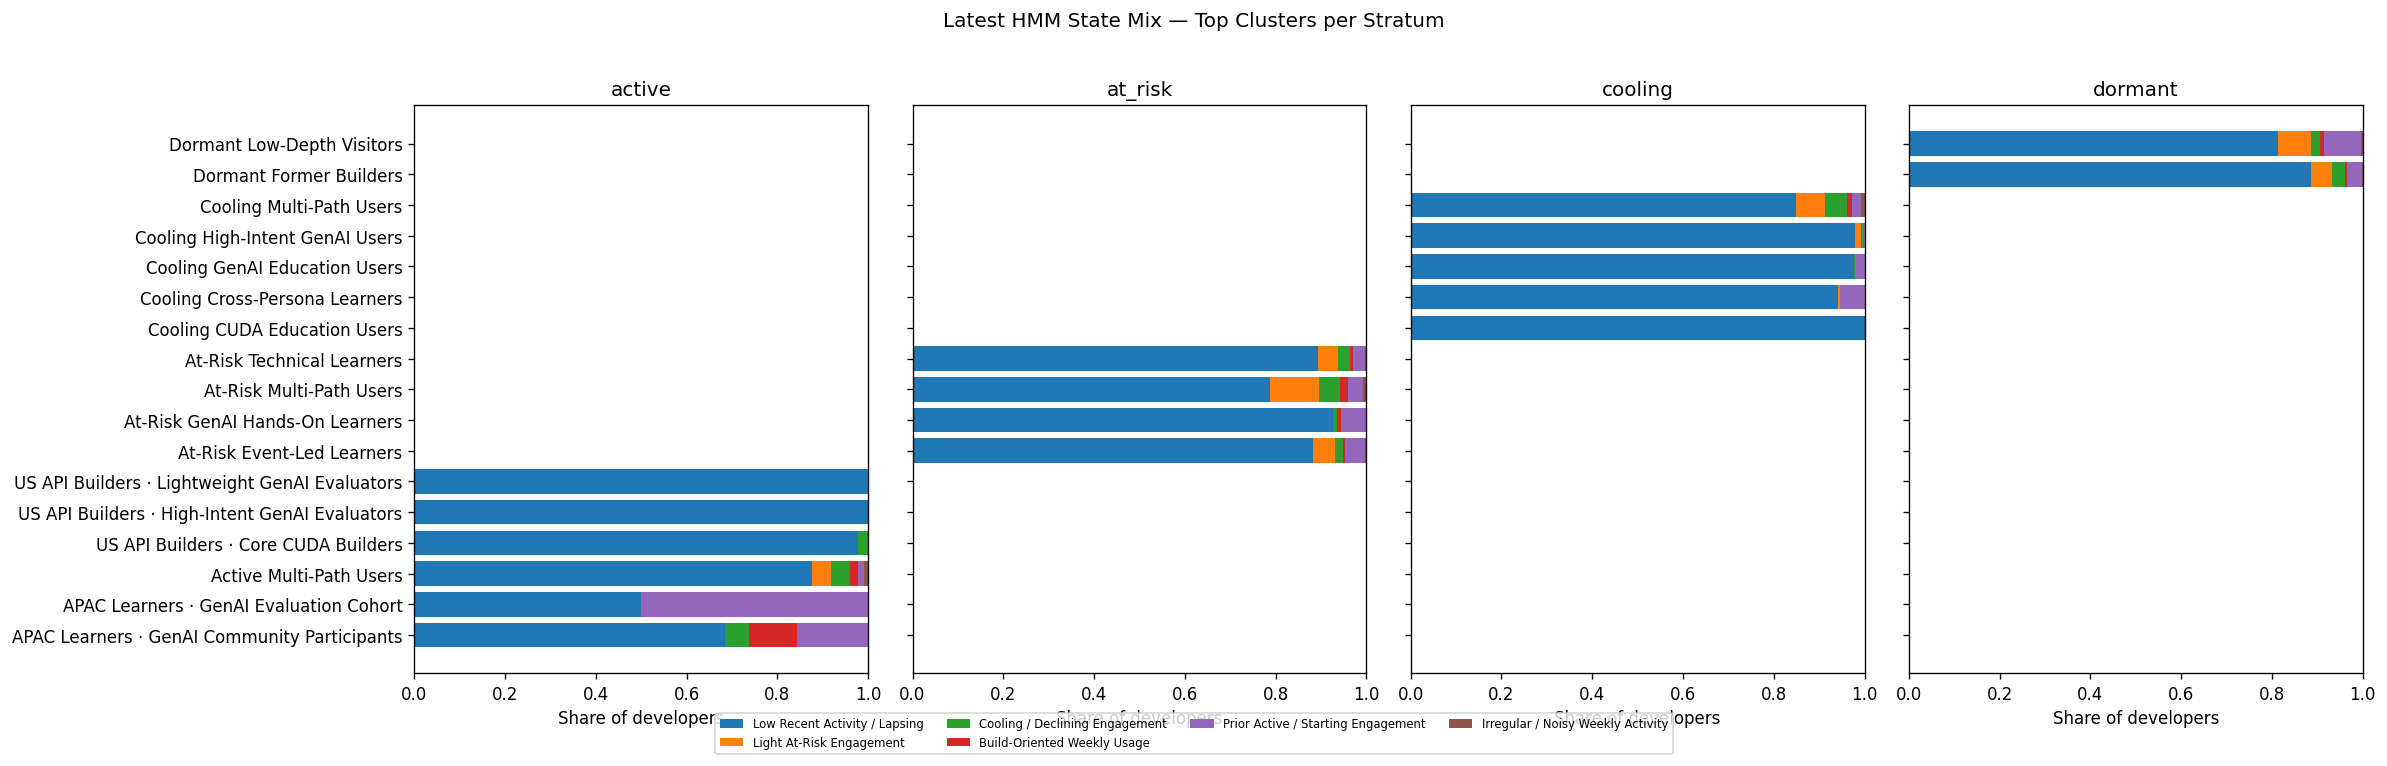

Saved: hmm_analysis_outputs_v2/cluster_latest_hmm_state_mix_v2.csv


,stratum,cluster_key,persona_feature_name,cluster_label_slide,hmm_hidden_state,hmm_state_label,n_developers,share_within_cluster
0,active,active_0,GenAI Evaluation Cohort,APAC Learners · GenAI Evaluation Cohort,6,Prior Active / Starting Engagement,6,0.500000
1,active,active_0,GenAI Evaluation Cohort,APAC Learners · GenAI Evaluation Cohort,1,Low Recent Activity / Lapsing,6,0.500000
2,active,active_1,Lightweight GenAI Evaluators,US API Builders · Lightweight GenAI Evaluators,1,Low Recent Activity / Lapsing,2144,0.997673
3,active,active_1,Lightweight GenAI Evaluators,US API Builders · Lightweight GenAI Evaluators,6,Prior Active / Starting Engagement,4,0.001861
4,active,active_1,Lightweight GenAI Evaluators,US API Builders · Lightweight GenAI Evaluators,2,Light At-Risk Engagement,1,0.000465
5,active,active_2,GenAI Community Participants,APAC Learners · GenAI Community Participants,1,Low Recent Activity / Lapsing,13,0.684211
6,active,active_2,GenAI Community Participants,APAC Learners · GenAI Community Participants,6,Prior Active / Starting Engagement,3,0.157895
7,active,active_2,GenAI Community Participants,APAC Learners · GenAI Community Participants,5,Build-Oriented Weekly Usage,2,0.105263
8,active,active_2,GenAI Community Participants,APAC Learners · GenAI Community Participants,3,Cooling / Declining Engagement,1,0.052632
9,active,active_3,High-Intent GenAI Evaluators,US API Builders · High-Intent GenAI Evaluators,1,Low Recent Activity / Lapsing,3099,0.999677


In [3]:
# 14.2 — latest HMM state mix by cluster
latest_mix = con.execute("""
WITH latest AS (
    SELECT
        w.developer_id,
        w.hmm_hidden_state,
        ROW_NUMBER() OVER (PARTITION BY w.developer_id ORDER BY w.week_start DESC) AS rn
    FROM dev_hmm_weekly_states_v1 w
    INNER JOIN v_hmm_valid_developers s
        ON w.developer_id = s.developer_id
),
latest_labeled AS (
    SELECT
        s.stratum,
        s.cluster_key,
        s.persona_feature_name,
        s.cluster_label_slide,
        l.hmm_hidden_state,
        lbl.hmm_state_label,
        l.developer_id
    FROM latest l
    JOIN v_hmm_valid_developers s
        ON l.developer_id = s.developer_id
    JOIN hmm_state_labels_v2_view lbl
        ON l.hmm_hidden_state = lbl.hmm_hidden_state
    WHERE l.rn = 1
)
SELECT
    stratum,
    cluster_key,
    persona_feature_name,
    cluster_label_slide,
    hmm_hidden_state,
    hmm_state_label,
    COUNT(*) AS n_developers
FROM latest_labeled
GROUP BY 1, 2, 3, 4, 5, 6
ORDER BY stratum, cluster_key, n_developers DESC
""").fetchdf()

latest_mix["share_within_cluster"] = (
    latest_mix.groupby(["stratum", "cluster_key"])["n_developers"].transform(lambda s: s / s.sum())
)

cluster_latest_hmm_state_mix_v2 = latest_mix.copy()

if WRITE_TABLES:
    con.register("_latest_mix", cluster_latest_hmm_state_mix_v2)
    con.execute("CREATE OR REPLACE TABLE cluster_latest_hmm_state_mix_v2 AS SELECT * FROM _latest_mix")
    con.unregister("_latest_mix")

cluster_sizes = (
    latest_mix.groupby(["stratum", "cluster_key", "cluster_label_slide"], as_index=False)["n_developers"]
    .sum()
)
top_clusters = (
    cluster_sizes.sort_values(["stratum", "n_developers"], ascending=[True, False])
    .groupby("stratum", as_index=False)
    .head(6)
)

plot_latest = latest_mix.merge(top_clusters[["stratum", "cluster_key"]], on=["stratum", "cluster_key"])
strata = sorted(plot_latest["stratum"].unique())
fig, axes = plt.subplots(1, len(strata), figsize=(5 * len(strata), 6), sharey=True)
if len(strata) == 1:
    axes = [axes]

for ax, stratum in zip(axes, strata):
    sub = plot_latest[plot_latest["stratum"] == stratum]
    pivot = sub.pivot_table(
        index="cluster_label_slide",
        columns="hmm_state_label",
        values="share_within_cluster",
        aggfunc="sum",
        fill_value=0,
    )
    bottom = np.zeros(len(pivot))
    for col in [c for c in state_label_order if c in pivot.columns]:
        ax.barh(pivot.index.astype(str), pivot[col].values, left=bottom, label=col)
        bottom += pivot[col].values
    ax.set_title(stratum)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Share of developers")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=7, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Latest HMM State Mix — Top Clusters per Stratum", y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "cluster_latest_hmm_state_mix.png", bbox_inches="tight")
plt.show()

latest_mix.to_csv(OUTPUT_DIR / "cluster_latest_hmm_state_mix_v2.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'cluster_latest_hmm_state_mix_v2.csv'}")
display(cluster_latest_hmm_state_mix_v2.head(12))


### 14.3 Common journey paths per cluster

Top **first → last** HMM state paths and dominant states within each cluster.

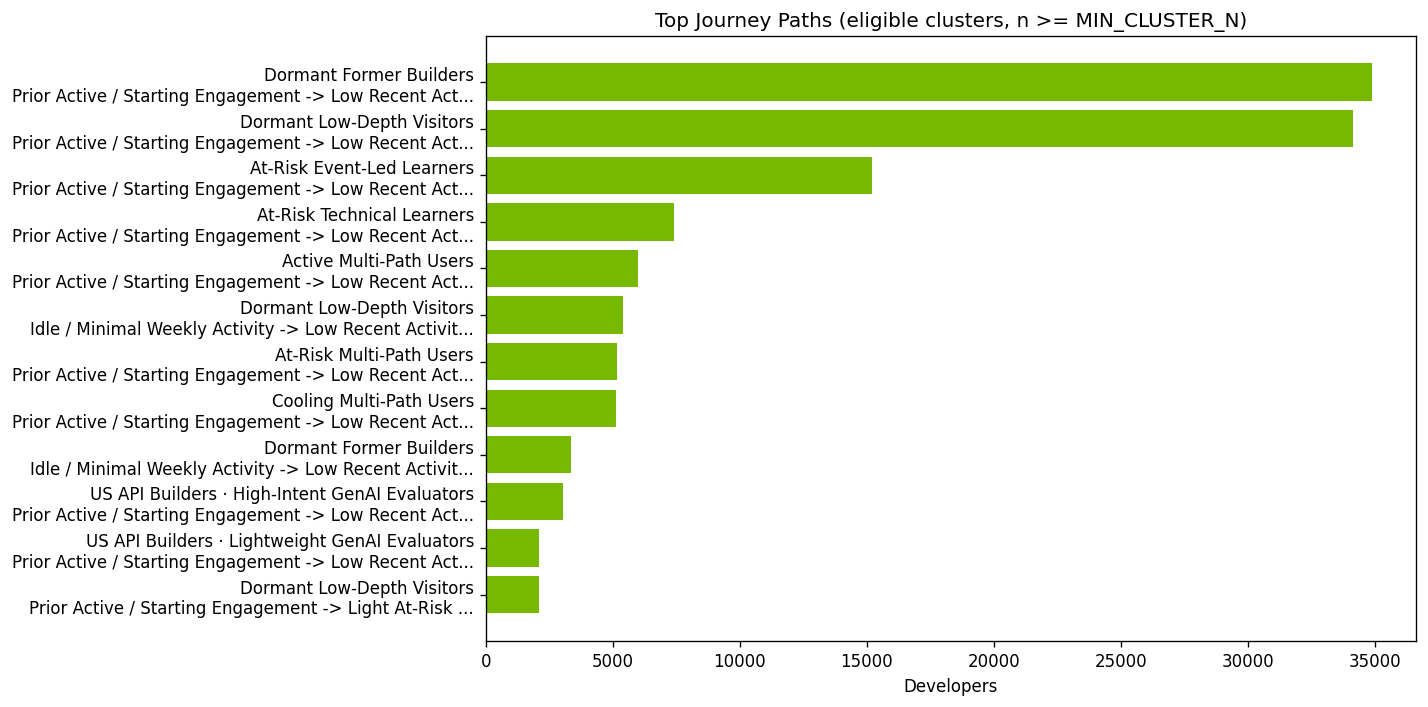

Saved: hmm_analysis_outputs_v2/cluster_journey_paths_v2.csv


,stratum,cluster_key,persona_feature_name,cluster_label_slide,journey_label,dominant_hmm_state_label,n_developers,avg_state_probability,avg_hmm_state_entropy,share_within_cluster,rank_within_cluster
0,active,active_0,GenAI Evaluation Cohort,APAC Learners · GenAI Evaluation Cohort,Prior Active / Starting Engagement -> Low Rece...,Low Recent Activity / Lapsing,4,0.805843,0.602486,0.333333,1.0
1,active,active_0,GenAI Evaluation Cohort,APAC Learners · GenAI Evaluation Cohort,Idle / Minimal Weekly Activity -> Prior Active...,Idle / Minimal Weekly Activity,3,0.598043,0.636514,0.250000,2.0
2,active,active_0,GenAI Evaluation Cohort,APAC Learners · GenAI Evaluation Cohort,Prior Active / Starting Engagement -> Prior Ac...,Prior Active / Starting Engagement,3,0.620802,0.424343,0.250000,3.0
3,active,active_0,GenAI Evaluation Cohort,APAC Learners · GenAI Evaluation Cohort,Prior Active / Starting Engagement -> Low Rece...,Prior Active / Starting Engagement,2,0.738356,0.636514,0.166667,4.0
4,active,active_1,Lightweight GenAI Evaluators,US API Builders · Lightweight GenAI Evaluators,Prior Active / Starting Engagement -> Low Rece...,Low Recent Activity / Lapsing,2113,0.792258,0.594302,0.983248,1.0
5,active,active_1,Lightweight GenAI Evaluators,US API Builders · Lightweight GenAI Evaluators,Idle / Minimal Weekly Activity -> Low Recent A...,Idle / Minimal Weekly Activity,21,0.638949,1.069595,0.009772,2.0
6,active,active_1,Lightweight GenAI Evaluators,US API Builders · Lightweight GenAI Evaluators,Idle / Minimal Weekly Activity -> Low Recent A...,Low Recent Activity / Lapsing,10,0.696306,1.033180,0.004653,3.0
7,active,active_1,Lightweight GenAI Evaluators,US API Builders · Lightweight GenAI Evaluators,Idle / Minimal Weekly Activity -> Prior Active...,Idle / Minimal Weekly Activity,3,0.598043,0.636514,0.001396,4.0
8,active,active_1,Lightweight GenAI Evaluators,US API Builders · Lightweight GenAI Evaluators,Idle / Minimal Weekly Activity -> Light At-Ris...,Light At-Risk Engagement,1,0.489726,0.500402,0.000465,5.0
9,active,active_2,GenAI Community Participants,APAC Learners · GenAI Community Participants,Prior Active / Starting Engagement -> Low Rece...,Low Recent Activity / Lapsing,12,0.657775,0.630333,0.631579,1.0


In [4]:
# 14.3 — journey paths per cluster (derived from all weekly rows)
journey_base = con.execute("""
SELECT
    s.*,
    lf.hmm_state_label AS first_hmm_state_label,
    ll.hmm_state_label AS last_hmm_state_label,
    ld.hmm_state_label AS dominant_hmm_state_label
FROM v_hmm_dev_journey_from_weekly s
JOIN hmm_state_labels_v2_view lf ON s.first_hmm_state = lf.hmm_hidden_state
JOIN hmm_state_labels_v2_view ll ON s.last_hmm_state = ll.hmm_hidden_state
JOIN hmm_state_labels_v2_view ld ON s.dominant_hmm_state = ld.hmm_hidden_state
""").fetchdf()

state_seq = con.execute("""
SELECT w.developer_id, w.hmm_hidden_state
FROM dev_hmm_weekly_states_v1 w
INNER JOIN v_hmm_valid_developers d ON w.developer_id = d.developer_id
""").fetchdf()


def _entropy(states: pd.Series) -> float:
    p = states.value_counts(normalize=True)
    return float(-(p * np.log2(p)).sum())


entropy_by_dev = (
    state_seq.groupby("developer_id")["hmm_hidden_state"]
    .apply(_entropy)
    .reset_index(name="hmm_state_entropy")
)
journey_base = journey_base.merge(entropy_by_dev, on="developer_id", how="left")

journey_base["journey_label"] = (
    journey_base["first_hmm_state_label"] + " -> " + journey_base["last_hmm_state_label"]
)

path_summary = (
    journey_base.groupby(
        [
            "stratum", "cluster_key", "persona_feature_name", "cluster_label_slide",
            "journey_label", "dominant_hmm_state_label",
        ],
        as_index=False,
    )
    .agg(
        n_developers=("developer_id", "count"),
        avg_state_probability=("avg_state_probability", "mean"),
        avg_hmm_state_entropy=("hmm_state_entropy", "mean"),
    )
)

path_summary["share_within_cluster"] = path_summary.groupby(["stratum", "cluster_key"])["n_developers"].transform(
    lambda s: s / s.sum()
)
path_summary["rank_within_cluster"] = path_summary.groupby(["stratum", "cluster_key"])["n_developers"].rank(
    ascending=False, method="first"
)

cluster_journey_paths_v2 = (
    path_summary[path_summary["rank_within_cluster"] <= 5]
    .sort_values(["stratum", "cluster_key", "n_developers"], ascending=[True, True, False])
    .reset_index(drop=True)
)

if WRITE_TABLES:
    con.register("_paths", cluster_journey_paths_v2)
    con.execute("CREATE OR REPLACE TABLE cluster_journey_paths_v2 AS SELECT * FROM _paths")
    con.unregister("_paths")

global_paths = (
    journey_base.groupby(["journey_label", "cluster_label_slide"], as_index=False)
    .size()
    .rename(columns={"size": "n_developers"})
    .sort_values("n_developers", ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(12, 6))
plot_labels = []
for row in global_paths.itertuples():
    jl = row.journey_label if len(row.journey_label) <= 55 else row.journey_label[:52] + "..."
    plot_labels.append(f"{row.cluster_label_slide}\n{jl}")
ax.barh(plot_labels[::-1], global_paths["n_developers"].values[::-1], color=NVIDIA_GREEN)
ax.set_xlabel("Developers")
ax.set_title("Top Journey Paths (all valid HMM-scored developers)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "cluster_top_journey_paths.png", bbox_inches="tight")
plt.show()

cluster_journey_paths_v2.to_csv(OUTPUT_DIR / "cluster_journey_paths_v2.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'cluster_journey_paths_v2.csv'}")
display(cluster_journey_paths_v2.head(15))


### 14.4 Per-cluster transition patterns

Top outgoing HMM transitions computed from weekly sequences (not the global transition matrix).

In [5]:
# 14.4 — per-cluster transition top pairs
trans_raw = con.execute("""
WITH weekly AS (
    SELECT
        s.stratum,
        s.cluster_key,
        s.persona_feature_name,
        s.cluster_label_slide,
        w.developer_id,
        w.week_start,
        w.hmm_hidden_state AS from_state,
        LEAD(w.hmm_hidden_state) OVER (
            PARTITION BY w.developer_id ORDER BY w.week_start
        ) AS to_state
    FROM dev_hmm_weekly_states_v1 w
    INNER JOIN v_hmm_valid_developers s
        ON w.developer_id = s.developer_id
),
pairs AS (
    SELECT
        stratum,
        cluster_key,
        persona_feature_name,
        cluster_label_slide,
        from_state,
        to_state,
        COUNT(*) AS n_transitions
    FROM weekly
    WHERE to_state IS NOT NULL
    GROUP BY 1, 2, 3, 4, 5, 6
)
SELECT
    p.stratum,
    p.cluster_key,
    p.persona_feature_name,
    p.cluster_label_slide,
    p.from_state,
    lf.hmm_state_label AS from_state_label,
    p.to_state,
    lt.hmm_state_label AS to_state_label,
    p.n_transitions
FROM pairs p
JOIN hmm_state_labels_v2_view lf ON p.from_state = lf.hmm_hidden_state
JOIN hmm_state_labels_v2_view lt ON p.to_state = lt.hmm_hidden_state
ORDER BY stratum, cluster_key, n_transitions DESC
""").fetchdf()

trans_raw["share_from_state_within_cluster"] = trans_raw.groupby(
    ["stratum", "cluster_key", "from_state"]
)["n_transitions"].transform(lambda s: s / s.sum())

trans_raw["transition_label"] = trans_raw["from_state_label"] + " -> " + trans_raw["to_state_label"]
trans_raw["rank_within_cluster"] = trans_raw.groupby(["stratum", "cluster_key"])["n_transitions"].rank(
    ascending=False, method="first"
)

cluster_transition_top_pairs_v2 = (
    trans_raw[trans_raw["rank_within_cluster"] <= 3]
    .sort_values(["stratum", "cluster_key", "n_transitions"], ascending=[True, True, False])
    .reset_index(drop=True)
)

if WRITE_TABLES:
    con.register("_trans", cluster_transition_top_pairs_v2)
    con.execute("CREATE OR REPLACE TABLE cluster_transition_top_pairs_v2 AS SELECT * FROM _trans")
    con.unregister("_trans")

EXEMPLAR_KEYS = ["active_5", "cooling_1", "at_risk_5", "at_risk_2", "Dormant_Former_Builders", "active_noise"]
exemplar = cluster_transition_top_pairs_v2[
    cluster_transition_top_pairs_v2["cluster_key"].isin(EXEMPLAR_KEYS)
].copy()

display(exemplar)

cluster_transition_top_pairs_v2.to_csv(OUTPUT_DIR / "cluster_transition_top_pairs_v2.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'cluster_transition_top_pairs_v2.csv'}")


,stratum,cluster_key,persona_feature_name,cluster_label_slide,from_state,from_state_label,to_state,to_state_label,n_transitions,share_from_state_within_cluster,transition_label,rank_within_cluster
14,active,active_5,Core CUDA Builders,US API Builders · Core CUDA Builders,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,85,0.977011,Prior Active / Starting Engagement -> Low Rece...,1.0
15,active,active_5,Core CUDA Builders,US API Builders · Core CUDA Builders,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,83,1.000000,Low Recent Activity / Lapsing -> Low Recent Ac...,2.0
16,active,active_5,Core CUDA Builders,US API Builders · Core CUDA Builders,0,Idle / Minimal Weekly Activity,6,Prior Active / Starting Engagement,10,0.909091,Idle / Minimal Weekly Activity -> Prior Active...,3.0
17,active,active_noise,Active Multi-Path Users,Active Multi-Path Users,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,50156,0.999203,Low Recent Activity / Lapsing -> Low Recent Ac...,1.0
18,active,active_noise,Active Multi-Path Users,Active Multi-Path Users,2,Light At-Risk Engagement,2,Light At-Risk Engagement,7589,0.973948,Light At-Risk Engagement -> Light At-Risk Enga...,2.0
19,active,active_noise,Active Multi-Path Users,Active Multi-Path Users,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,6568,0.883033,Prior Active / Starting Engagement -> Low Rece...,3.0
26,at_risk,at_risk_5,At-Risk Event-Led Learners,At-Risk Event-Led Learners,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,54039,0.999519,Low Recent Activity / Lapsing -> Low Recent Ac...,1.0
27,at_risk,at_risk_5,At-Risk Event-Led Learners,At-Risk Event-Led Learners,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,17072,0.857372,Prior Active / Starting Engagement -> Low Rece...,2.0
28,at_risk,at_risk_5,At-Risk Event-Led Learners,At-Risk Event-Led Learners,2,Light At-Risk Engagement,2,Light At-Risk Engagement,6226,0.986219,Light At-Risk Engagement -> Light At-Risk Enga...,3.0
46,dormant,Dormant_Former_Builders,Dormant Former Builders,Dormant Former Builders,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,123163,0.999586,Low Recent Activity / Lapsing -> Low Recent Ac...,1.0


Saved: hmm_analysis_outputs_v2/cluster_transition_top_pairs_v2.csv


### 14.5 Journey archetype tags + targeting profile

Rule-based journey archetypes and suggested intervention templates per cluster.

In [6]:
# 14.5 — cluster targeting profile

def top_journey_for_cluster(cluster_key):
    sub = cluster_journey_paths_v2[cluster_journey_paths_v2["cluster_key"] == cluster_key]
    if sub.empty:
        return None, None, np.nan
    row = sub.iloc[0]
    return row["journey_label"], row["dominant_hmm_state_label"], row["share_within_cluster"]


def top_transition_for_cluster(cluster_key):
    sub = cluster_transition_top_pairs_v2[cluster_transition_top_pairs_v2["cluster_key"] == cluster_key]
    if sub.empty:
        return None, np.nan
    row = sub.iloc[0]
    return row["transition_label"], row["share_from_state_within_cluster"]


def state_shares(cluster_key, states):
    sub = state_dist[state_dist["cluster_key"] == cluster_key]
    if sub.empty:
        return 0.0
    return sub[sub["hmm_hidden_state"].isin(states)]["share_within_cluster"].sum()


def latest_state_shares(cluster_key, states):
    sub = latest_mix[latest_mix["cluster_key"] == cluster_key]
    if sub.empty:
        return 0.0
    return sub[sub["hmm_hidden_state"].isin(states)]["share_within_cluster"].sum()


INTERVENTIONS = {
    "training_to_inactive": "Post-DLI deployment pathway / ship-to-prod nudge",
    "event_spike_dropoff": "Post-event 30-day activation journey (GTC / webinar follow-up)",
    "recoverable": "Win-back with NIM / Agentic AI tooling",
    "cooling_decline": "Re-engagement drip: light-touch eval → build milestone",
    "stable_engaged": "Deepen API usage / expand to production workflows",
    "sparse_cluster": "Insufficient sample — validate before targeting",
}

cluster_meta = (
    journey_base.groupby(
        ["stratum", "cluster_key", "persona_feature_name", "cluster_label_slide"],
        as_index=False,
    )
    .agg(n_developers=("developer_id", "count"))
)
demo_cols = journey_base[
    ["cluster_key", "demographic_audience", "demographic_archetypes", "is_ghost_cluster"]
].drop_duplicates("cluster_key")
cluster_meta = cluster_meta.merge(demo_cols, on="cluster_key", how="left")

rows = []
for _, row in cluster_meta.iterrows():
    ck = row["cluster_key"]
    tags = []

    if row["n_developers"] < SPARSE_CLUSTER_N:
        tags.append("sparse_cluster")

    engaged_share = state_shares(ck, {4, 5, 6})
    lapse_share = state_shares(ck, {0, 1})
    cooling_share = state_shares(ck, {3, 1})
    latest_recover = latest_state_shares(ck, {5, 6})

    if engaged_share >= 0.25 and lapse_share <= 0.55:
        tags.append("stable_engaged")
    if cooling_share >= 0.45:
        tags.append("cooling_decline")

    top_journey, top_dominant, top_journey_share = top_journey_for_cluster(ck)
    top_trans, top_trans_share = top_transition_for_cluster(ck)

    persona = (row["persona_feature_name"] or "").lower()
    if "training" in persona and top_journey and top_journey.startswith("Prior Active"):
        tags.append("training_to_inactive")
    if "event" in persona and top_journey and "Active Exploration Burst" in top_journey:
        tags.append("event_spike_dropoff")
    if row["stratum"] in {"at_risk", "cooling", "dormant"} and latest_recover >= 0.08:
        tags.append("recoverable")

    tags = list(dict.fromkeys(tags))
    primary_tag = tags[0] if tags else "mixed_pattern"

    intervention = INTERVENTIONS.get(primary_tag, "Review cluster journey mix before campaign design")

    rows.append({
        "stratum": row["stratum"],
        "cluster_key": ck,
        "persona_feature_name": row["persona_feature_name"],
        "cluster_label_slide": row["cluster_label_slide"],
        "demographic_audience": row["demographic_audience"],
        "demographic_archetypes": row["demographic_archetypes"],
        "is_ghost_cluster": row["is_ghost_cluster"],
        "n_developers": row["n_developers"],
        "journey_archetype_tags": "; ".join(tags) if tags else "mixed_pattern",
        "primary_journey_archetype": primary_tag,
        "top_journey_label": top_journey,
        "top_journey_share": top_journey_share,
        "top_dominant_state_label": top_dominant,
        "top_transition_label": top_trans,
        "top_transition_share": top_trans_share,
        "engaged_state_week_share": engaged_share,
        "lapse_state_week_share": lapse_share,
        "latest_recoverable_state_share": latest_recover,
        "suggested_intervention": intervention,
    })

cluster_targeting_profile_v2 = pd.DataFrame(rows).sort_values(
    ["stratum", "n_developers"], ascending=[True, False]
)

if WRITE_TABLES:
    con.register("_profile", cluster_targeting_profile_v2)
    con.execute("CREATE OR REPLACE TABLE cluster_targeting_profile_v2 AS SELECT * FROM _profile")
    con.unregister("_profile")

display(cluster_targeting_profile_v2)
cluster_targeting_profile_v2.to_csv(OUTPUT_DIR / "cluster_targeting_profile_v2.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'cluster_targeting_profile_v2.csv'}")


,stratum,cluster_key,persona_feature_name,cluster_label_slide,demographic_audience,demographic_archetypes,is_ghost_cluster,n_developers,journey_archetype_tags,primary_journey_archetype,top_journey_label,top_journey_share,top_dominant_state_label,top_transition_label,top_transition_share,engaged_state_week_share,lapse_state_week_share,latest_recoverable_state_share,suggested_intervention
6,active,active_noise,Active Multi-Path Users,Active Multi-Path Users,NaN,NaN,False,7531,cooling_decline,cooling_decline,Prior Active / Starting Engagement -> Low Rece...,0.785287,Low Recent Activity / Lapsing,Low Recent Activity / Lapsing -> Low Recent Ac...,0.999203,0.118321,0.695777,0.029877,Re-engagement drip: light-touch eval → build m...
3,active,active_3,High-Intent GenAI Evaluators,US API Builders · High-Intent GenAI Evaluators,US API Builders,NaN,False,3100,cooling_decline,cooling_decline,Prior Active / Starting Engagement -> Low Rece...,0.987097,Low Recent Activity / Lapsing,Low Recent Activity / Lapsing -> Low Recent Ac...,1.000000,0.138220,0.861780,0.000323,Re-engagement drip: light-touch eval → build m...
1,active,active_1,Lightweight GenAI Evaluators,US API Builders · Lightweight GenAI Evaluators,US API Builders,NaN,False,2149,cooling_decline,cooling_decline,Prior Active / Starting Engagement -> Low Rece...,0.983248,Low Recent Activity / Lapsing,Low Recent Activity / Lapsing -> Low Recent Ac...,1.000000,0.277613,0.721871,0.001861,Re-engagement drip: light-touch eval → build m...
5,active,active_5,Core CUDA Builders,US API Builders · Core CUDA Builders,US API Builders,NaN,False,87,cooling_decline,cooling_decline,Prior Active / Starting Engagement -> Low Rece...,0.850575,Low Recent Activity / Lapsing,Prior Active / Starting Engagement -> Low Rece...,0.977011,0.327206,0.658088,0.000000,Re-engagement drip: light-touch eval → build m...
2,active,active_2,GenAI Community Participants,APAC Learners · GenAI Community Participants,APAC Learners,NaN,False,19,sparse_cluster; cooling_decline,sparse_cluster,Prior Active / Starting Engagement -> Low Rece...,0.631579,Low Recent Activity / Lapsing,Low Recent Activity / Lapsing -> Low Recent Ac...,1.000000,0.350000,0.566667,0.263158,Insufficient sample — validate before targeting
0,active,active_0,GenAI Evaluation Cohort,APAC Learners · GenAI Evaluation Cohort,APAC Learners,NaN,False,12,sparse_cluster; stable_engaged,sparse_cluster,Prior Active / Starting Engagement -> Low Rece...,0.333333,Low Recent Activity / Lapsing,Prior Active / Starting Engagement -> Low Rece...,0.500000,0.473684,0.526316,0.500000,Insufficient sample — validate before targeting
4,active,active_4,Event-Driven GenAI Evaluators,APAC Learners · Event-Driven GenAI Evaluators,APAC Learners,NaN,False,7,sparse_cluster; cooling_decline,sparse_cluster,Prior Active / Starting Engagement -> Low Rece...,1.000000,Low Recent Activity / Lapsing,Prior Active / Starting Engagement -> Low Rece...,1.000000,0.333333,0.666667,0.000000,Insufficient sample — validate before targeting
9,at_risk,at_risk_5,At-Risk Event-Led Learners,At-Risk Event-Led Learners,NaN,NaN,False,19325,cooling_decline,cooling_decline,Prior Active / Starting Engagement -> Low Rece...,0.763105,Low Recent Activity / Lapsing,Low Recent Activity / Lapsing -> Low Recent Ac...,0.999519,0.199723,0.696529,0.049832,Re-engagement drip: light-touch eval → build m...
7,at_risk,at_risk_0,At-Risk Technical Learners,At-Risk Technical Learners,NaN,NaN,False,9305,cooling_decline,cooling_decline,Prior Active / Starting Engagement -> Low Rece...,0.776679,Low Recent Activity / Lapsing,Low Recent Activity / Lapsing -> Low Recent Ac...,0.999237,0.173599,0.703284,0.032886,Re-engagement drip: light-touch eval → build m...
10,at_risk,at_risk_noise,At-Risk Multi-Path Users,At-Risk Multi-Path Users,NaN,NaN,False,7731,cooling_decline,cooling_decline,Prior Active / Starting Engagement -> Low Rece...,0.654120,Low Recent Activity / Lapsing,Low Recent Activity / Lapsing -> Low Recent Ac...,0.999515,0.128106

Saved: hmm_analysis_outputs_v2/cluster_targeting_profile_v2.csv


### 14.6 Export cluster × journey outputs

In [7]:
# 14.6 — export all Section 14 artifacts
section14_tables = {
    "cluster_hmm_state_distribution_v2": cluster_hmm_state_distribution_v2,
    "cluster_latest_hmm_state_mix_v2": cluster_latest_hmm_state_mix_v2,
    "cluster_journey_paths_v2": cluster_journey_paths_v2,
    "cluster_transition_top_pairs_v2": cluster_transition_top_pairs_v2,
    "cluster_targeting_profile_v2": cluster_targeting_profile_v2,
}

manifest = []
for name, df in section14_tables.items():
    csv_path = OUTPUT_DIR / f"{name}.csv"
    pq_path = OUTPUT_DIR / f"{name}.parquet"
    df.to_csv(csv_path, index=False)
    df.to_parquet(pq_path, index=False)
    manifest.append({"table_name": name, "rows": len(df), "csv": csv_path.as_posix(), "parquet": pq_path.as_posix()})
    print(f"Exported {name}: {len(df):,} rows")

manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv(OUTPUT_DIR / "cluster_journey_analysis_manifest.csv", index=False)
display(manifest_df)

sparse = cluster_targeting_profile_v2.query("n_developers < @SPARSE_CLUSTER_N")
print("\nCoverage summary")
print(f"  Clusters profiled: {len(cluster_targeting_profile_v2)}")
print(f"  Sparse clusters (n < {SPARSE_CLUSTER_N}, annotated only): {len(sparse)}")
if len(sparse):
    print("  Sparse cluster keys:", ", ".join(sparse["cluster_key"].tolist()))


Exported cluster_hmm_state_distribution_v2: 107 rows
Exported cluster_latest_hmm_state_mix_v2: 71 rows
Exported cluster_journey_paths_v2: 80 rows
Exported cluster_transition_top_pairs_v2: 52 rows
Exported cluster_targeting_profile_v2: 18 rows


,table_name,rows,csv,parquet
0,cluster_hmm_state_distribution_v2,107,hmm_analysis_outputs_v2/cluster_hmm_state_dist...,hmm_analysis_outputs_v2/cluster_hmm_state_dist...
1,cluster_latest_hmm_state_mix_v2,71,hmm_analysis_outputs_v2/cluster_latest_hmm_sta...,hmm_analysis_outputs_v2/cluster_latest_hmm_sta...
2,cluster_journey_paths_v2,80,hmm_analysis_outputs_v2/cluster_journey_paths_...,hmm_analysis_outputs_v2/cluster_journey_paths_...
3,cluster_transition_top_pairs_v2,52,hmm_analysis_outputs_v2/cluster_transition_top...,hmm_analysis_outputs_v2/cluster_transition_top...
4,cluster_targeting_profile_v2,18,hmm_analysis_outputs_v2/cluster_targeting_prof...,hmm_analysis_outputs_v2/cluster_targeting_prof...



Coverage summary
  Clusters profiled: 18
  Sparse clusters (n < 30): 4
  Sparse cluster keys: active_2, active_0, active_4, cooling_3


## 15. Close connection


In [8]:
con.close()
print("Done.")

Done.
